# Lab 1, Core A: Least squares, conditioning, and $QR$
### <div align="right"> Linear Algebra for Data Science, MSc DS &mdash; UCU APPS </div>
### <div align="right"> adapted from a 2022 assignment by Ostap Dyhdalovych and Volodymyr Kuchynskyi </div>

## Completed by:
*   Vladyslav Hryhola
*   Ihor Kashuba


### What this core is about

Fitting a model to data is a least squares problem, and you have seen the formula. This
notebook is about the gap between the formula and an algorithm: **the same mathematics,
implemented two ways, stops agreeing** once the problem is hard enough, and one of the two
ways is wrong long before it looks wrong.

You will fit a trend-plus-seasonality model to 166 years of monthly temperature readings,
raise the complexity of the model until your two solvers disagree, and find out which one
to believe and why.

### Marking

This is **Core A** of Lab 1. The lab is worth 6 points: 2 for this core, 2 for Core B
(the DFT), 1 for the code, and up to 1 for extensions. Core marks are awarded at the
**oral defence**, not from the notebook alone, so a correct result you cannot explain is
worth less than a partial result you understand. Individual cells carry no separate marks.

**Bonus.** The three extensions are the only route to the bonus point. They are marked
$\star$ and sit at the **end** of the notebook they build on: Extensions 1 and 2 at the end
of this one, Extension 3 at the end of Core B. Attempt at most one; a second earns nothing.

Questions marked *harder &mdash; not required* go beyond the course material. They earn no
extra points, are marked generously, and are there to be discussed at the defence.

### Ground rules

* Sections 1-4: implement the linear algebra yourself with basic `numpy`. You may use
  `np.linalg.qr`, `np.linalg.solve`, `np.linalg.cond` and `np.linalg.norm`.
* Always write `np.linalg.qr(A, mode="reduced")` with the mode given **explicitly**.
  The default has not been stable across numpy versions, and `mode="complete"` returns
  an $m \times m$ matrix $Q$ that does not fit the formulas used here.
* **`np.linalg.inv` is forbidden throughout.** If you find yourself wanting it, that is
  the notebook working as intended &mdash; see Question 1.1.
* `np.linalg.lstsq` is allowed **only** where explicitly asked for, as a reference answer.
* Where a cell asks you to *predict* before computing, write the prediction down first.
  A prediction written after the fact teaches nothing, and the defence will ask.


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd

np.set_printoptions(precision=4, suppress=False)

DATA_FILE = "data/land-temp-1850-2015.csv"   # supplied with the lab

# Report your environment. The last digits in section 3 depend on the
# LAPACK build behind numpy, so two machines can legitimately differ.
print("numpy", np.__version__, "| pandas", pd.__version__)


numpy 2.5.3 | pandas 3.0.6


---
## 0. The data

Average monthly temperatures, January 1850 to December 2015: 1992 readings, no gaps.

### Where this comes from, and what it is

This is the `LandAverageTemperature` column of `GlobalTemperatures.csv` from the Berkeley
Earth *Climate Change: Earth Surface Temperature Data* collection, distributed on Kaggle
under CC BY-NC-SA 4.0. Berkeley Earth builds it by combining roughly 1.6 billion
temperature reports from 16 pre-existing archives, including NOAA's MLOST, NASA's GISTEMP
and the UK's HadCRUT.

Four things about it are worth knowing **before** you model it:

1. **It is a global land average, not a place.** One number per month for the entire land
   surface of the Earth. There is no city, country or station to reason about, and no
   local conclusion to draw.
2. **The seasonal swing is the Northern Hemisphere's**, because that is where most of the
   land is. The two hemispheres' summers do not cancel; the larger one wins.
3. **The series starts in 1750, and we use it from 1850.** That is not arbitrary. The
   original column has twelve missing months scattered through 1750-1752, and the early
   record carries much larger stated uncertainties. Berkeley Earth's own maximum, minimum
   and land-and-ocean columns all begin in 1850 for the same reason. Restricting to 1850
   buys a series with **no gaps and uniform monthly spacing** &mdash; which Core B needs
   absolutely, since a transform has no way to represent a month that is not there.
4. **Every value is an estimate with an error bar.** The file ships a companion
   `LandAverageTemperatureUncertainty` column, a 95% confidence half-width, which is large
   early and small late. Ordinary least squares assumes all observations are equally
   trustworthy. That assumption is false here, and one of the extension tasks is about
   what to do instead.


In [2]:
temp_data = pd.read_csv(DATA_FILE)
temp_data["date"] = pd.to_datetime(temp_data["date"])

N = temp_data.shape[0]
y = temp_data["avg_temp"].to_numpy()

# The time index is FLOAT, and that is not cosmetic. np.arange(N) gives
# int64, and t**k for k >= 6 then silently wraps around: at degree 10 the
# last entry comes out negative. numpy issues no warning. Integer overflow
# is not one of the failure modes this notebook is about -- keep it out.
t_month = np.arange(N, dtype=float)         # 0.0, 1.0, ..., N-1

print(f"N = {N} readings, {temp_data['date'].min():%Y-%m} to {temp_data['date'].max():%Y-%m}")
print(f"missing values: {temp_data.isna().sum().sum()}")
temp_data.describe()


N = 1992 readings, 1850-01 to 2015-12
missing values: 0


,date,avg_temp
count,1992,1992.000000
mean,1932-12-16 00:11:33.975904,8.571583
min,1850-01-01 00:00:00,0.404000
25%,1891-06-23 12:00:00,4.430000
50%,1932-12-16 12:00:00,8.850500
75%,1974-06-08 12:00:00,12.858500
max,2015-12-01 00:00:00,15.482000
std,NaN,4.263193


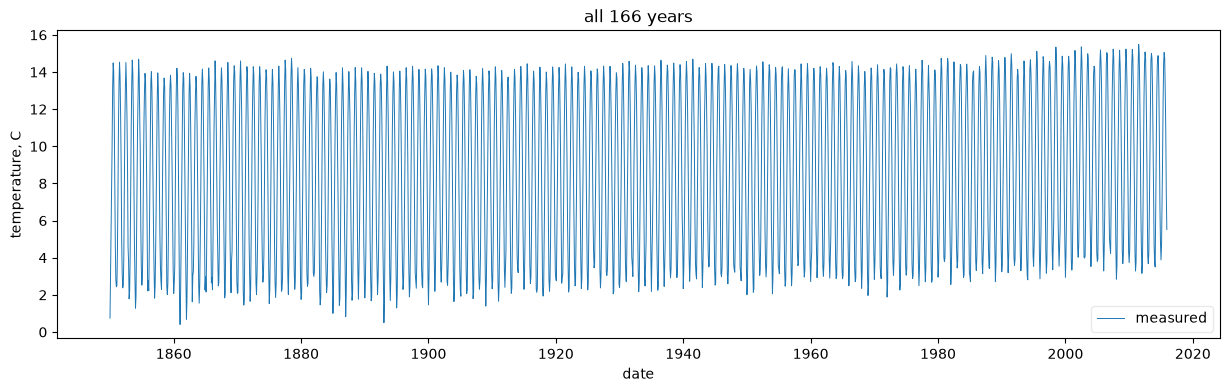

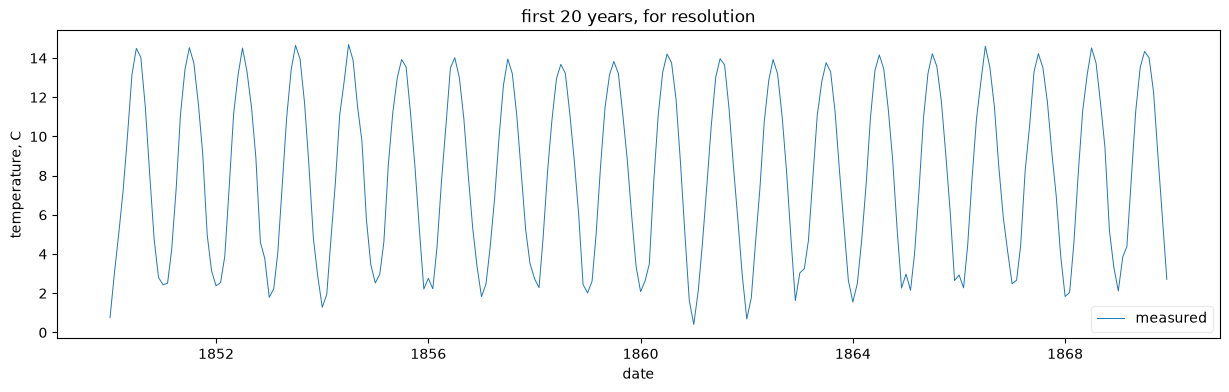

In [3]:
def plot_temps(time, data, prediction=None, title=None):
    plt.figure(figsize=(15, 4))
    plt.plot(time, data, lw=0.7, label="measured")
    if prediction is not None:
        plt.plot(time, prediction, lw=1.2, label="model")
    plt.xlabel("date"); plt.ylabel("temperature, C")
    if title: plt.title(title)
    plt.legend(framealpha=0.4); plt.show()


def RMSE(predicted, reference):
    return np.sqrt(np.mean((predicted - reference) ** 2))


plot_temps(temp_data["date"], y, title="all 166 years")
plot_temps(temp_data["date"][:240], y[:240], title="first 20 years, for resolution")


### **0.1** What do you see?

Describe the series in two or three sentences: what varies fast, what varies slowly, and
roughly how large each is. You will build a model with one term for each.

---
_Answer_. The series shows seasonal cycles, temperatures rises and falls. The full record show slower upward trend of a few degrees up, which is much smaller than the seasonal variation.

---
## 1. Three routes to the same solution

For a design matrix $A$ with linearly independent columns and a data vector $\mathbf{y}$,
the least squares solution $\hat{\mathbf{x}} = \arg\min \|A\mathbf{x} - \mathbf{y}\|$ is
characterised by the residual being orthogonal to $\mathbf{Col}(A)$, equivalently by the
**normal equation**
$$ A^{\top}A\,\hat{\mathbf{x}} = A^{\top}\mathbf{y}. $$
Using the reduced factorization $A = QR$ with $Q^\top Q = I$, the same solution satisfies
$$ R\,\hat{\mathbf{x}} = Q^{\top}\mathbf{y}, $$
an upper-triangular system. These two are **equivalent in exact arithmetic** &mdash; you proved
this in the tutorial. You will now implement both and find out what that equivalence is
worth in floating point.


### **1.1** Why is `inv` forbidden?

The textbook formula is $\hat{\mathbf{x}} = (A^{\top}A)^{-1}A^{\top}\mathbf{y}$, and it is
correct. Give **two separate reasons** &mdash; one about cost, one about accuracy &mdash; why no
library computes it that way. Then state what is computed instead.

---
_Answer._
- **Cost:** Computing $(A^T A)^{-1}$ explicitly is unnecessary and more expensive because we only need the solution vector, not the full inverse matrix.

- **Accuracy:** Explicit inversion introduces additional floating-point rounding error, so it is less numerically accurate than solving the linear system directly.

Instead, we form $A^T A$ and $A^T y$ and solve $(A^T A)\hat{x} = A^T y$ using a linear-system solver such as `np.linalg.solve`.

---


In [4]:
def solve_normal_equation(A: np.ndarray, y: np.ndarray) -> np.ndarray:
    """Least squares via the normal equation.

    Form the matrix A^T A and the vector A^T y, then solve the resulting
    square system. Do NOT invert anything: np.linalg.solve takes a system,
    not an inverse.

    Args:
        A: (m, n) design matrix, m > n, independent columns
        y: (m,) data vector
    Returns:
        (n,) coefficient vector
    """
    assert A.ndim == 2 and y.ndim == 1 and A.shape[0] == y.shape[0]

    # ========= YOUR CODE STARTS HERE ========= #
    ATA = A.T @ A
    ATy = A.T @ y
    coeffs = np.linalg.solve(ATA, ATy)
    # ========== YOUR CODE ENDS HERE ========== #

    return coeffs


In [5]:
def back_substitution(R: np.ndarray, b: np.ndarray) -> np.ndarray:
    """Solve R x = b for upper-triangular R, by hand.

    Work from the last row upwards. Do not call np.linalg.solve here: the
    point is that this costs O(n^2), not O(n^3), and you should see why.
    """
    n = R.shape[0]
    x = np.zeros(n)
    # ========= YOUR CODE STARTS HERE ========= #

    # Start from the last row and move upward:
    for i in range(n - 1, -1, -1):
        # R[i, i+1:]      -> coefficients to the right of the diagonal
        # x[i+1:]         -> already known variables
        # their dot product is the already-known contribution
        known_part = R[i, i + 1:] @ x[i + 1:]

        # Move the known contribution to the right-hand side
        rhs = b[i] - known_part

        # Divide by the diagonal coefficient R[i, i]
        # to solve for the current unknown x[i]
        x[i] = rhs / R[i, i]

    # ========== YOUR CODE ENDS HERE ========== #
    return x


def solve_qr(A: np.ndarray, y: np.ndarray) -> np.ndarray:
    """Least squares via the reduced QR factorization.

    Use np.linalg.qr(A, mode='reduced') to get Q and R, then solve
    -- pass mode explicitly, never rely on the default -- and then solve
    R x = Q^T y with your back_substitution. A^T A must never be formed.
    """
    assert A.ndim == 2 and y.ndim == 1 and A.shape[0] == y.shape[0]

    # ========= YOUR CODE STARTS HERE ========= #
    # Factor the design matrix:
    Q, R = np.linalg.qr(A, mode="reduced")

    # Compute the right-hand side of the QR least-squares system:
    #
    # R x_hat = Q^T y
    rhs = Q.T @ y

    # R is upper triangular, so solve it efficiently
    # using our own back-substitution function
    coeffs = back_substitution(R, rhs)
    # ========== YOUR CODE ENDS HERE ========== #
    return coeffs


def solve_reference(A: np.ndarray, y: np.ndarray) -> np.ndarray:
    """Trusted reference. This is the only sanctioned use of lstsq."""
    return np.linalg.lstsq(A, y, rcond=None)[0]


In [6]:
def test_solvers():
    rng = np.random.default_rng(0)
    A = rng.standard_normal((40, 4))          # well conditioned by construction
    x_true = np.array([1.0, -2.0, 0.5, 3.0])
    y_ = A @ x_true + 0.01 * rng.standard_normal(40)

    xn, xq, xr = solve_normal_equation(A, y_), solve_qr(A, y_), solve_reference(A, y_)
    for name, x in (("normal equation", xn), ("QR", xq)):
        assert isinstance(x, np.ndarray), f"{name}: not implemented yet"
        assert np.allclose(x, xr, atol=1e-10), f"{name} disagrees with the reference"
    print(f"cond(A) = {np.linalg.cond(A):.2e}")
    print("TEST 1: SUCCESS -- all three routes agree on an easy problem")

test_solvers()


cond(A) = 1.49e+00
TEST 1: SUCCESS -- all three routes agree on an easy problem


### **1.2** Residual orthogonality

Take the fit from the test above and verify numerically that the residual
$\mathbf{r} = \mathbf{y} - A\hat{\mathbf{x}}$ is orthogonal to every column of $A$.
Report $\|A^{\top}\mathbf{r}\|$ and say what value would count as "zero" here, and why it
is not exactly zero.

Then verify Pythagoras: $\|\mathbf{y}\|^2 = \|A\hat{\mathbf{x}}\|^2 + \|\mathbf{r}\|^2$.


In [7]:
# ========= YOUR CODE STARTS HERE ========= #
# Recreate the same deterministic test problem used in test_solvers()
rng = np.random.default_rng(0)

A = rng.standard_normal((40, 4))
x_true = np.array([1.0, -2.0, 0.5, 3.0])
y_ = A @ x_true + 0.01 * rng.standard_normal(40)

# Compute the least-squares solution using our QR solver
x_hat = solve_qr(A, y_)

# Fitted vector A x_hat: the projection of y onto Col(A)
y_hat = A @ x_hat

# Residual: the part of y that the model could not fit
r = y_ - y_hat

# For a least-squares solution, r should be orthogonal
# to every column of A, so A^T r should be approximately zero.
orthogonality_error = np.linalg.norm(A.T @ r)

print(f"||A^T r|| = {orthogonality_error:.3e}")

# Verify Pythagoras:
# y = y_hat + r, and y_hat is orthogonal to r,
# therefore ||y||^2 = ||y_hat||^2 + ||r||^2.
lhs = np.linalg.norm(y_) ** 2
rhs = np.linalg.norm(y_hat) ** 2 + np.linalg.norm(r) ** 2

print(f"||y||^2                 = {lhs:.15f}")
print(f"||A x_hat||^2 + ||r||^2 = {rhs:.15f}")
print(f"difference              = {abs(lhs - rhs):.3e}")
# ========== YOUR CODE ENDS HERE ========== #


||A^T r|| = 4.417e-14
||y||^2                 = 493.092304163105780
||A x_hat||^2 + ||r||^2 = 493.092304163105894
difference              = 1.137e-13


---
_Answer._
- The residual is numerically orthogonal to the columns of $A$ because

  $$\|A^T r\| \approx 4.42 \times 10^{-14},$$

  which is small enough to count as zero here. It is not exactly zero because the QR factorization and the following arithmetic are performed in finite-precision floating-point arithmetic.

- Pythagoras is also satisfied numerically:

  $$\|y\|^2 \approx 493.092304163105780,$$

  $$\|A\hat{x}\|^2 + \|r\|^2 \approx 493.092304163105894.$$

  Their difference is only about $1.14 \times 10^{-13}$, which is again due to floating-point rounding.

---


---
## 2. A model for monthly temperature

The series has a slow component and a fast one. Model the slow part by a polynomial in
time and the fast part by one pair of trigonometric functions at the annual period
$T = 12$ months:
$$ F(t) \;=\; \underbrace{a_0 + a_1 t + \dots + a_d t^{d}}_{\text{trend, degree } d}
\;+\; \underbrace{b_1\cos\frac{2\pi t}{T} + b_2\sin\frac{2\pi t}{T}}_{\text{seasonality}}. $$

This is still **linear least squares**: $F$ is non-linear in $t$ but linear in the
unknowns $a_0,\dots,a_d,b_1,b_2$, and that is all the method requires. Each basis
function becomes one column of $A$.


### **2.1** Build the design matrix

Note the `t` argument: it is the time variable *as you choose to measure it*. That
choice looks cosmetic. Section 4 is about how badly it is not.


In [8]:
def design_matrix(t: np.ndarray, degree: int, period: float = 12.0,
                  seasonal: bool = True,
                  month_index: np.ndarray = None) -> np.ndarray:
    """Columns: 1, t, t^2, ..., t^degree, then optionally cos and sin.

    Args:
        t:           time variable for the POLYNOMIAL columns, in whatever
                     units you choose. Pass a float array.
        month_index: time variable for the SEASONAL columns, which must stay
                     in months whatever you do to `t` -- the period is 12
                     months and rescaling `t` must not silently rescale it.
                     Defaults to 0, 1, ..., len(t)-1.

    Returns:
        (len(t), degree + 1 + 2*seasonal) design matrix
    """
    t = np.asarray(t, dtype=float)
    if month_index is None:
        month_index = np.arange(t.shape[0], dtype=float)

    # ========= YOUR CODE STARTS HERE ========= #

    # Build polynomial feature columns:
    # 1, t, t^2, ..., t^degree
    columns = [t ** k for k in range(degree + 1)]

    if seasonal:
        # Convert the month index into an angle.
        # With period=12, one full 2π cycle corresponds to 12 months.
        angle = 2 * np.pi * month_index / period

        # Add the two seasonal basis functions as extra columns.
        # These depend on month_index, not on t.
        columns.append(np.cos(angle))
        columns.append(np.sin(angle))

    # Combine all feature vectors into one design matrix,
    # with each feature becoming one column.
    A = np.column_stack(columns)

    # ========== YOUR CODE ENDS HERE ========== #
    return A


def test_design_matrix():
    A = design_matrix(np.arange(24, dtype=float), degree=2)
    assert A.shape == (24, 5), f"expected (24, 5), got {A.shape}"
    assert np.allclose(A[:, 0], 1.0), "first column should be the constant term"
    assert np.allclose(A[:, 1], np.arange(24)), "second column should be t"

    # rescaling t must NOT change the seasonal columns
    B = design_matrix(np.linspace(0, 1, 24), degree=2,
                      month_index=np.arange(24, dtype=float))
    assert np.allclose(A[:, -2:], B[:, -2:]), "seasonal columns moved when t was rescaled"
    print("TEST 2: SUCCESS")

test_design_matrix()


TEST 2: SUCCESS


### **2.2** Fit the linear-trend model and look at it

Fit with `degree=1` on the raw month index, using **any** of your three solvers, and plot.
Report the RMSE, and report the trend coefficient in degrees per century &mdash; a number a
non-mathematician could be told.


trend: 0.853 °C per century


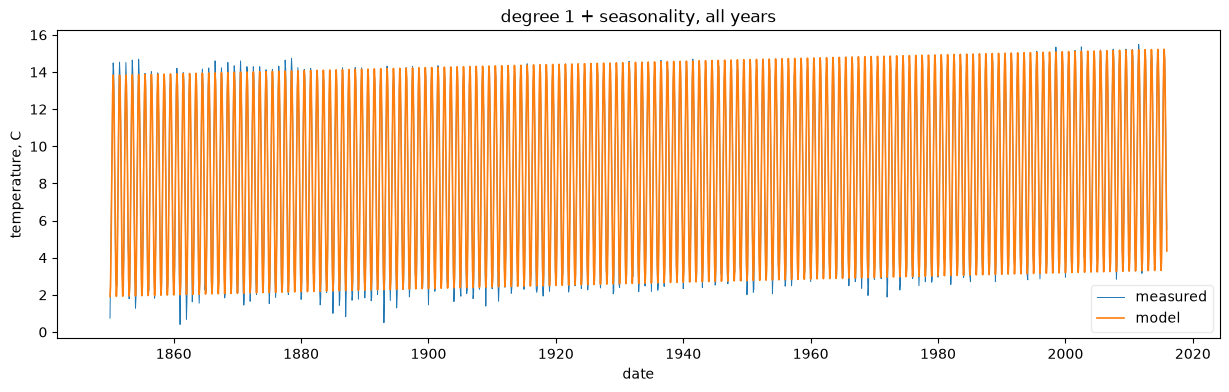

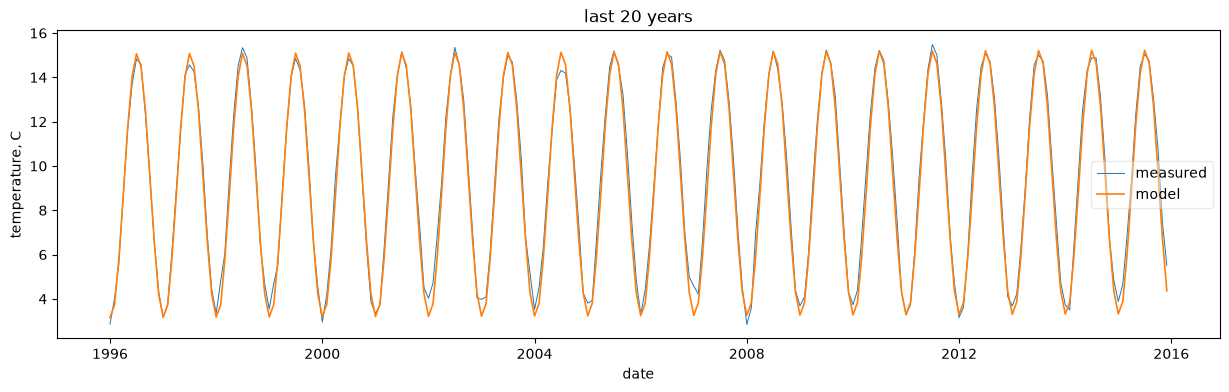

RMSE: 0.4181075834851416


In [9]:
# ========= YOUR CODE STARTS HERE ========= #
# Build the design matrix for:
# 1, t, cos(2πm/12), sin(2πm/12)
# because degree=1 gives the constant + linear trend,
# and seasonal=True adds the annual cosine/sine pair.
A1 = design_matrix(t_month, degree=1)

# Solve the least-squares problem.
# We use the QR solver here because it avoids forming A^T A.
coeffs1 = solve_qr(A1, y)

# Compute the fitted temperatures A x_hat.
fit1 = A1 @ coeffs1

# coeffs1[1] is the linear trend in degrees Celsius per month.
# There are 1200 months in 100 years.
trend_per_century = coeffs1[1] * 1200

print(f"trend: {trend_per_century:.3f} °C per century")
# ========== YOUR CODE ENDS HERE ========== #

plot_temps(temp_data["date"], y, fit1, title="degree 1 + seasonality, all years")
plot_temps(temp_data["date"][-240:], y[-240:], fit1[-240:], title="last 20 years")
print("RMSE:", RMSE(fit1, y))


### **2.3** Does the seasonal pair earn its place?

Refit with `seasonal=False` and compare the RMSE. Report both numbers and the ratio.
In one sentence: which of the two components of the model carries more of the signal?

*(Keep this number. Core B will recover the same fact from the data without being told
that the period is 12.)*


In [10]:
# ========= YOUR CODE STARTS HERE ========= #

# Build the same degree-1 trend model, but remove
# the seasonal cosine/sine columns.
A_no_season = design_matrix(t_month, degree=1, seasonal=False)

# Fit the reduced model using the same QR solver.
coeffs_no_season = solve_qr(A_no_season, y)

# Compute predicted temperatures.
fit_no_season = A_no_season @ coeffs_no_season

# Compare prediction errors with and without seasonality.
rmse_with_season = RMSE(fit1, y)
rmse_without_season = RMSE(fit_no_season, y)

# Ratio > 1 means the model without seasonality is worse.
rmse_ratio = rmse_without_season / rmse_with_season

print(f"RMSE with seasonality:    {rmse_with_season:.6f}")
print(f"RMSE without seasonality: {rmse_without_season:.6f}")
print(f"RMSE ratio:               {rmse_ratio:.3f}")

# ========== YOUR CODE ENDS HERE ========== #


RMSE with seasonality:    0.418108
RMSE without seasonality: 4.241809
RMSE ratio:               10.145


---
_Answer._ With seasonality, the RMSE is about 0.418, while without it the RMSE jumps to about 4.242. So the fit is roughly 10 times worse without the seasonal terms, which makes it pretty clear that seasonality carries much more of the signal than the long-term trend.

---


---
## 3. Raise the degree until the routes disagree

A degree-1 trend is a strong assumption. The obvious move is to let the polynomial be
more flexible and see whether the fit improves. So sweep the degree and watch what
happens &mdash; not to the fit, but to the *solvers*.


### **3.1** Predict first

Before running anything, write down your prediction. As the degree $d$ grows from 1 to 12,
on the raw month index $t = 0, 1, \dots, 1991$:

1. What will happen to $\operatorname{cond}(A)$? Guess an order of magnitude at $d = 6$.
2. Which solver will fail first, and at roughly which degree?
3. Will the *fitted curves* from the two solvers look different on a plot?

---
1. I expect $\operatorname{cond}(A)$ to get much larger as the degree increases, because higher powers like $t^5$ or $t^6$ become much bigger than the lower-degree columns. At $d=6$, I would guess it is somewhere around $10^{15}$ to $10^{20}$.

2. I expect the normal-equation solver to start giving inaccurate results before QR, because it forms $A^T A$. I would guess this starts happening somewhere around degree 5 or 6.

3. I think the fitted curves may still look quite similar at first, even when the solver coefficients start to disagree.

---


In [11]:
def sweep(t: np.ndarray, y: np.ndarray, degrees=range(0, 13)) -> pd.DataFrame:
    """For each degree: cond(A), cond(A^T A), and how far each solver is from
    the reference, measured as a relative error in the coefficient vector."""
    rows = []
    for d in degrees:
        A = design_matrix(t, degree=d, month_index=t_month)
        # ========= YOUR CODE STARTS HERE ========= #
        # Condition number of the original design matrix A
        cA = np.linalg.cond(A)

        # Form A^T A explicitly and measure its condition number
        AtA = A.T @ A
        cAtA = np.linalg.cond(AtA)

        # Trusted least-squares reference solution
        xr = solve_reference(A, y)

        # Solutions from our two implementations
        x_ne = solve_normal_equation(A, y)
        x_qr = solve_qr(A, y)

        # Relative error of the normal-equation coefficients
        # compared with the reference solution
        e_ne = np.linalg.norm(x_ne - xr) / np.linalg.norm(xr)

        # Relative error of the QR coefficients
        # compared with the reference solution
        e_qr = np.linalg.norm(x_qr - xr) / np.linalg.norm(xr)

        # RMSE of the reference fitted curve
        fit_ref = A @ xr
        rmse = RMSE(fit_ref, y)
        # ========== YOUR CODE ENDS HERE ========== #
        rows.append(dict(degree=d, cond_A=cA, cond_AtA=cAtA,
                         err_normal=e_ne, err_qr=e_qr, rmse=rmse))
    return pd.DataFrame(rows).set_index("degree")


raw = sweep(t_month, y)
raw.style.format({"cond_A": "{:.2e}", "cond_AtA": "{:.2e}",
                  "err_normal": "{:.2e}", "err_qr": "{:.2e}", "rmse": "{:.4f}"})


,cond_A,cond_AtA,err_normal,err_qr,rmse
degree,,,,,
0,1.41e+00,2.00e+00,1.37e-15,1.22e-15,0.5848
1,2.30e+03,5.28e+06,1.73e-15,9.54e-16,0.4181
2,5.32e+06,2.83e+13,1.29e-14,2.63e-15,0.4031
3,1.19e+10,1.42e+20,1.23e-11,1.22e-11,0.3992
4,2.61e+13,5.50e+25,2.10e+02,2.10e+02,4.5397
5,5.48e+16,1.78e+32,1.06e+05,1.06e+05,5.0220
6,7.61e+20,5.99e+38,7.90e+07,7.90e+07,5.4683
7,2.87e+24,2.06e+45,7.58e+10,7.58e+10,5.8521
8,5.77e+28,7.20e+51,4.86e+17,4.86e+17,6.9231


### **3.2** What actually happened

Compare the table against your prediction, point by point. In particular:

1. At which degree does `err_normal` first exceed $10^{-6}$? At which does `err_qr`?
2. Something has gone wrong that the lecture did **not** predict: $QR$ fails too, and at
   almost the same degree. The $QR$ route never forms $A^{\top}A$, so the
   $\operatorname{cond}(A)^2$ argument does not apply to it. Why is it failing anyway?
3. Look at the last column. Does the RMSE warn you that anything is wrong?

---
_Answer._
1. Both solvers first exceed an error of $10^{-6}$ at degree 4. I expected the normal-equation solver to fail before QR, but in this experiment they start failing at almost the same point.

2. QR avoids forming $A^T A$, but the original matrix $A$ is already extremely ill-conditioned. The columns $1,t,t^2,\ldots$ have very different scales when $t$ goes up to 1991, so QR cannot completely fix the numerical problems caused by the design matrix itself.

3. Yes. The RMSE is around $0.4$ up to degree 3, but jumps to about $4.54$ at degree 4 and then keeps increasing, so in this case the RMSE clearly warns that something has gone wrong.

---


### **3.3** Diagnose the design matrix

Print the column norms of $A$ at $d = 6$ on the raw month index. Report the ratio of the
largest to the smallest. Then answer: is the *problem* ill-conditioned, or is this
particular *matrix* badly built? Those are different diagnoses with different cures.


In [12]:
# ========= YOUR CODE STARTS HERE ========= #
# Build the degree-6 design matrix on the raw month index.
A6 = design_matrix(t_month, degree=6, month_index=t_month)

# Compute the Euclidean norm of each column.
# axis=0 means: compute one norm per column.
column_norms = np.linalg.norm(A6, axis=0)

# Compare the largest and smallest column scales.
ratio = column_norms.max() / column_norms.min()

print("column norms:")
for i, norm in enumerate(column_norms):
    print(f"column {i}: {norm:.3e}")

print(f"\nlargest / smallest ratio: {ratio:.3e}")

# ========== YOUR CODE ENDS HERE ========== #


column norms:
column 0: 4.463e+01
column 1: 5.131e+04
column 2: 7.915e+07
column 3: 1.332e+11
column 4: 2.340e+14
column 5: 4.215e+17
column 6: 7.721e+20
column 7: 3.156e+01
column 8: 3.156e+01

largest / smallest ratio: 2.447e+19


---
_Answer._ The column norms differ by about $2.45 \times 10^{19}$, which is an enormous scale difference. So the main issue is not that the underlying fitting problem is inherently ill-conditioned, but that this particular design matrix is badly built: powers of the raw month index become huge very quickly. Rescaling the time variable should improve the conditioning without changing the actual model being fitted.

---


---
## 4. The one-line fix

The columns $1, t, t^2, \dots, t^{d}$ with $t$ running to $1991$ have wildly different
scales: the last column is of order $10^{19}$ while the first is $1$. Rescale time to the
unit interval, $s = t / (N-1) \in [0, 1]$, and repeat. Nothing about the *model* changes
&mdash; the span of the columns is identical, so the fitted curve is mathematically the same
function. Only the coordinates change.


In [13]:
s = t_month / (N - 1)                      # rescaled time, in [0, 1]

scaled = sweep(s, y)
scaled.style.format({"cond_A": "{:.2e}", "cond_AtA": "{:.2e}",
                     "err_normal": "{:.2e}", "err_qr": "{:.2e}", "rmse": "{:.4f}"})


,cond_A,cond_AtA,err_normal,err_qr,rmse
degree,,,,,
0,1.41e+00,2.00e+00,1.37e-15,1.22e-15,0.5848
1,4.39e+00,1.93e+01,4.46e-15,1.64e-15,0.4181
2,2.29e+01,5.23e+02,1.02e-13,1.86e-15,0.4031
3,1.24e+02,1.55e+04,1.49e-12,6.73e-15,0.3992
4,6.89e+02,4.75e+05,2.09e-12,5.41e-14,0.3951
5,3.86e+03,1.49e+07,4.83e-10,3.51e-14,0.3946
6,2.17e+04,4.73e+08,2.56e-08,3.08e-13,0.3895
7,1.23e+05,1.52e+10,3.33e-08,4.41e-13,0.3878
8,7.00e+05,4.89e+11,1.75e-05,5.55e-13,0.3867


### **4.1** Now the lecture's prediction should hold

1. Plot `err_normal` and `err_qr` against degree on a log scale, for the scaled design.
2. At which degree do the two curves first separate by more than one order of magnitude?
3. The rule of thumb says the normal-equation route loses about
   $\log_{10}\operatorname{cond}(A)^2$ decimal digits, against $\log_{10}\operatorname{cond}(A)$
   for $QR$. Check this against your table at $d = 8$ and $d = 12$: predict the number of
   correct digits from the condition number, then count the digits you actually got.
4. At which degree does $\operatorname{cond}(A^{\top}A)$ exceed $1/\varepsilon_{\mathrm{mach}}$?
   What does that mean for the matrix `A.T @ A` that your first solver just formed?


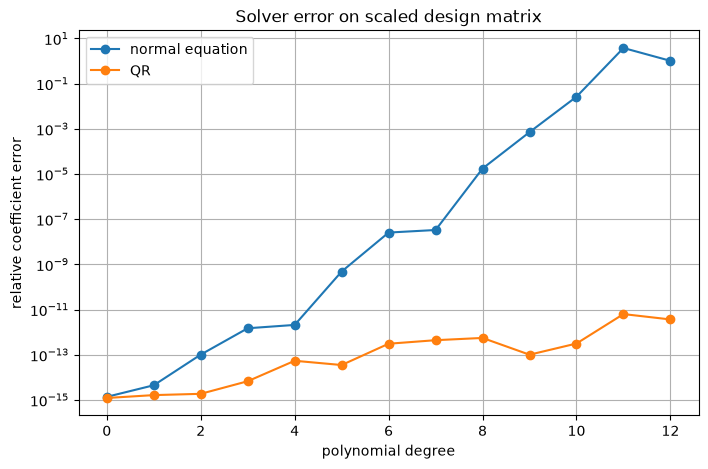

first separation by > 10x: 2
machine epsilon: 2.220e-16
1 / epsilon:     4.504e+15

degree 8:
  cond(A) = 6.995e+05
  normal: predicted digits ≈ 4.31, actual ≈ 4.76
  QR:     predicted digits ≈ 10.16, actual ≈ 12.26

degree 12:
  cond(A) = 7.459e+08
  normal: predicted digits ≈ -1.75, actual ≈ -0.01
  QR:     predicted digits ≈ 7.13, actual ≈ 11.44

first degree with cond(A^T A) > 1/eps: 11


In [14]:
# ========= YOUR CODE STARTS HERE ========= #
# Plot the relative coefficient errors for both solvers.
# Log scale is useful because the errors may differ by many orders of magnitude.
plt.figure(figsize=(8, 5))
plt.semilogy(scaled.index, scaled["err_normal"], marker="o", label="normal equation")
plt.semilogy(scaled.index, scaled["err_qr"], marker="o", label="QR")
plt.xlabel("polynomial degree")
plt.ylabel("relative coefficient error")
plt.title("Solver error on scaled design matrix")
plt.legend()
plt.grid(True)
plt.show()


# Find the first degree where the two errors differ
# by more than one order of magnitude (factor > 10).
error_ratio = np.maximum(
    scaled["err_normal"] / scaled["err_qr"],
    scaled["err_qr"] / scaled["err_normal"]
)

separated = scaled.index[error_ratio > 10]
first_separation = separated[0] if len(separated) > 0 else None

print("first separation by > 10x:", first_separation)


# Double-precision machine epsilon: roughly 2.22e-16.
eps = np.finfo(float).eps
print(f"machine epsilon: {eps:.3e}")
print(f"1 / epsilon:     {1 / eps:.3e}")


# Check degrees 8 and 12.
# Roughly 16 decimal digits are available in float64.
for d in [8, 12]:
    cond_A = scaled.loc[d, "cond_A"]
    err_ne = scaled.loc[d, "err_normal"]
    err_qr = scaled.loc[d, "err_qr"]

    # Predicted correct digits:
    # normal equations lose about log10(cond(A)^2)
    # QR loses about log10(cond(A))
    predicted_ne = 16 - np.log10(cond_A ** 2)
    predicted_qr = 16 - np.log10(cond_A)

    # Actual correct digits estimated from relative error.
    actual_ne = -np.log10(err_ne)
    actual_qr = -np.log10(err_qr)

    print(f"\ndegree {d}:")
    print(f"  cond(A) = {cond_A:.3e}")
    print(f"  normal: predicted digits ≈ {predicted_ne:.2f}, actual ≈ {actual_ne:.2f}")
    print(f"  QR:     predicted digits ≈ {predicted_qr:.2f}, actual ≈ {actual_qr:.2f}")


# Find the first degree where cond(A^T A) becomes larger
# than 1 / machine epsilon.
too_ill_conditioned = scaled.index[scaled["cond_AtA"] > 1 / eps]
first_bad_AtA = too_ill_conditioned[0] if len(too_ill_conditioned) > 0 else None

print("\nfirst degree with cond(A^T A) > 1/eps:", first_bad_AtA)

# ========== YOUR CODE ENDS HERE ========== #


---
1. The two solver errors first differ by more than one order of magnitude at degree 2. After that, the normal-equation error grows much faster, while QR stays very small.

2. At $d=8$, $\operatorname{cond}(A) \approx 7.0 \times 10^5$. The rule of thumb predicts about 4.3 correct digits for the normal equations and 10.2 for QR; in practice we got about 4.8 and 12.3 digits. At $d=12$, the normal equations are predicted to have essentially no reliable digits left, while QR is predicted to keep about 7.1; the measured errors show the same overall pattern, with QR still much more accurate.

3. The rule of thumb is not exact, but it correctly predicts the main behavior: forming $A^T A$ makes the normal-equation route lose accuracy much faster than QR.

4. $\operatorname{cond}(A^T A)$ first exceeds $1/\varepsilon_{\mathrm{mach}}$ at degree 11. At that point, $A^T A$ is effectively too ill-conditioned for double-precision arithmetic to represent its important differences reliably, so solving the normal equations becomes numerically unsafe.

---


### **4.2** The cost of the fix

Rescaling cost one line and no flops. Ill-conditioning that disappears under a change of
units was never a property of the underlying problem &mdash; it was a property of the
*coordinates you chose to state it in*.

So: is the ill-conditioning you saw in Section 3 real or artificial? Is the residual
ill-conditioning in Section 4 &mdash; which rescaling did **not** remove &mdash; real or artificial?
*Harder &mdash; not required for full marks; we will discuss it at the defence:* say how you
would tell the two apart in general, for a problem where you cannot see the answer.

---
_Answer._ The extreme ill-conditioning in Section 3 was mostly artificial. It came from using the raw month index, which made columns such as $t^6$ enormously larger than the constant and seasonal columns. Rescaling time to $[0,1]$ removed most of that problem without changing the model.

The remaining ill-conditioning in Section 4 is more genuine: even after rescaling, high-degree polynomial columns become increasingly similar to each other, so estimating their coefficients is still sensitive. In general, I would try sensible rescaling or a better-conditioned basis; if the condition number drops dramatically without changing the model space, the original problem was mostly caused by the chosen coordinates.

---


---
## 5. Coefficients and predictions are not equally hard

At $d = 12$ on the scaled design, solve the problem both ways and compare **two** things:
the coefficient vectors, and the fitted curves.


relative coefficient difference: 1.024e+00
relative prediction difference:  6.794e-04
normal-equation RMSE: 0.386570
QR RMSE:              0.386515


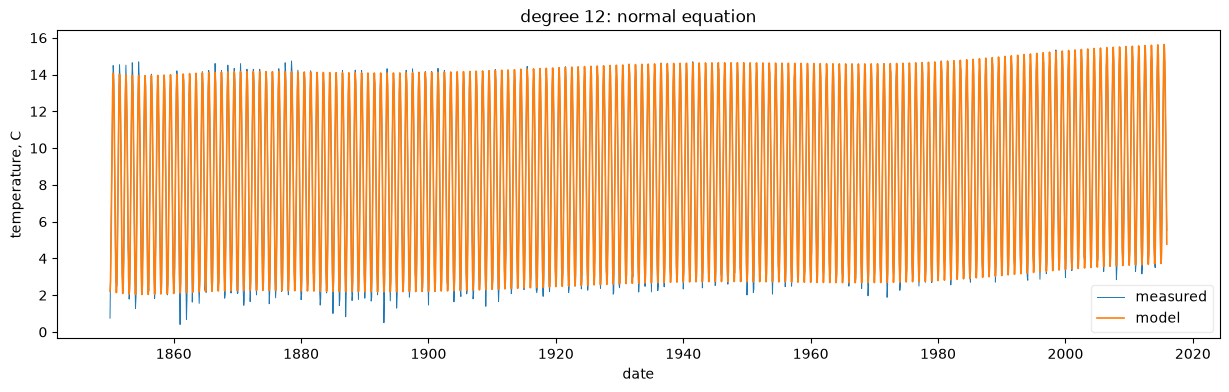

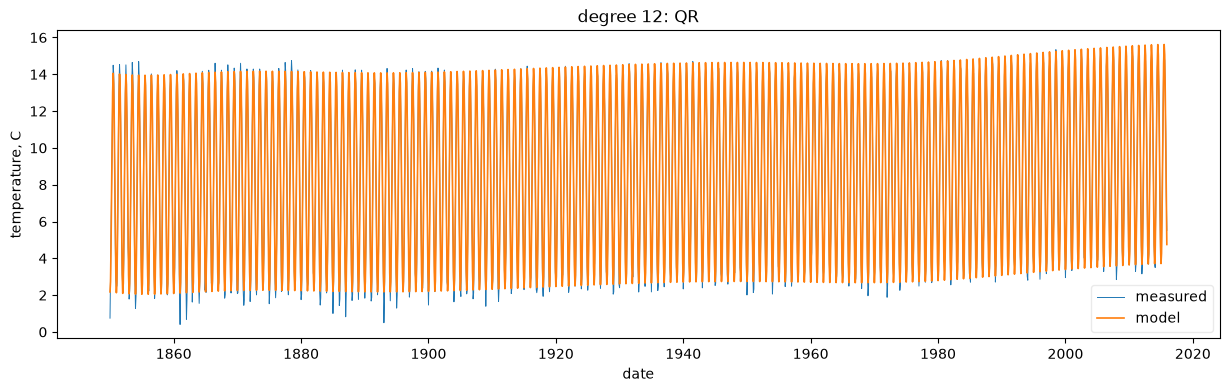

In [15]:
d = 12
A = design_matrix(s, degree=d, month_index=t_month)

# ========= YOUR CODE STARTS HERE ========= #
# Solve the same degree-12 least-squares problem
# using the normal-equation route and the QR route.
x_ne = solve_normal_equation(A, y)
x_qr = solve_qr(A, y)

# Compare the coefficient vectors.
# QR is used as the reference scale in the denominator.
coeff_diff = np.linalg.norm(x_ne - x_qr) / np.linalg.norm(x_qr)

# Compute the fitted temperature curves produced by both solutions.
fit_ne = A @ x_ne
fit_qr = A @ x_qr

# Compare the predictions themselves.
pred_diff = np.linalg.norm(fit_ne - fit_qr) / np.linalg.norm(fit_qr)

print(f"relative coefficient difference: {coeff_diff:.3e}")
print(f"relative prediction difference:  {pred_diff:.3e}")

# RMSE is useful for checking whether the two fitted curves
# still look similarly good against the actual data.
print(f"normal-equation RMSE: {RMSE(fit_ne, y):.6f}")
print(f"QR RMSE:              {RMSE(fit_qr, y):.6f}")
# ========== YOUR CODE ENDS HERE ========== #

plot_temps(temp_data["date"], y, A @ x_ne, title=f"degree {d}: normal equation")
plot_temps(temp_data["date"], y, A @ x_qr, title=f"degree {d}: QR")


### **5.1**

One of the two comparisons exposes the damage and the other hides it. Which, by how many
orders of magnitude, and **why**?

Then the consequence, in one paragraph: if you had judged these two fits by plotting them,
or by their RMSE, what would you have concluded? Name one situation in data science where
you need the coefficients themselves and not just the predictions &mdash; and one where the
predictions are genuinely all you need.

---
_Answer._ The coefficient comparison exposes the problem: the relative difference is about 1.02, so the two coefficient vectors are very different. But the fitted predictions differ by only about $6.8 \times 10^{-4}$, which is roughly three orders of magnitude smaller. This happens because the high-degree polynomial basis is ill-conditioned: quite different coefficient combinations can cancel each other out and still produce almost the same fitted curve.

If I judged the two solutions only by the plots or RMSE, I would probably conclude that they are basically the same fit - the RMSE values are 0.386570 and 0.386515, and the curves look almost identical. But that would hide the fact that the normal-equation coefficients are unreliable. The coefficients themselves matter when we want to interpret a regression model, for example to say how strongly a feature affects the target. On the other hand, for a pure forecasting task where I only care about accurate predictions, the fitted outputs may be all I need.

---


---
## 6. Summary

Answer in a few sentences each. These are the questions the defence will start from.

1. You implemented one piece of mathematics two ways and they disagreed. State precisely
   what the disagreement was caused by, and which of the two answers was right.
2. Given a new least squares problem tomorrow, what would you compute *before* choosing a
   solver, and what would you do with the number?
3. What is the largest $\operatorname{cond}(A)$ at which you would still trust the normal
   equation in double precision, and where does your threshold come from?
4. Which degree of trend would you actually report for this series, and on what grounds?
   Note that this is a modelling question, not a numerical one &mdash; the numerically safest
   fit is not automatically the one to publish.

---
_Answer._

1. The disagreement was caused by numerical instability, not by different mathematics. The normal-equation method forms $A^T A$, which makes the conditioning much worse, while QR avoids this. So the QR result is the one I would trust more.

2. I would first compute $\operatorname{cond}(A)$. If it is small, the problem is numerically well behaved; if it is large, I would avoid the normal equations and prefer QR or another more stable method. I would also check whether simple rescaling improves the condition number.

3. As a rough upper limit, I would stop trusting the normal equation when $\operatorname{cond}(A)$ gets close to about $10^8$. This comes from $\operatorname{cond}(A^T A) \approx \operatorname{cond}(A)^2$ and the fact that double precision has $\varepsilon_{\mathrm{mach}} \approx 2.2 \times 10^{-16}$, so $\sqrt{1/\varepsilon_{\mathrm{mach}}}$ is around $10^8$.

4. I would probably report a degree-1 trend. Higher degrees reduce the RMSE only a little, while making the model more complicated and harder to interpret. A linear trend is simple, stable, and already captures the main long-term change in the series.

---


---
---
# $\star$ Extensions (bonus)

> **Optional. Up to 1 bonus point for the whole lab.** Attempt **at most one** of the three
> extensions &mdash; Extensions 1 and 2 are below, Extension 3 is at the end of Core B. A
> second extension earns nothing, and a shallow attempt at one earns nothing either: the
> point is for a **finding you can defend**, not for code that ran. Say in your `README`
> which one you chose.

Everything above this line is Core A and is marked in full without these.


---
## $\star$ Extension 1 (bonus): Weighted least squares on the full record

Ordinary least squares treats every observation as equally trustworthy. This series is
not: every month comes with a 95% uncertainty half-width $\sigma_j$, which is large in the
18th century and small today. Weighted least squares minimises
$$ \sum_j w_j\,\big(y_j - (A\mathbf{x})_j\big)^2, \qquad w_j = 1/\sigma_j^2, $$
whose solution satisfies $A^{\top}WA\,\hat{\mathbf{x}} = A^{\top}W\mathbf{y}$ with
$W = \operatorname{diag}(w_j)$.

The data file for this extension is supplied: `land-temp-1750-2015-with-uncertainty.csv`,
with columns `date`, `avg_temp` and `uncertainty`, 3192 months from January 1750. It is
the same Berkeley Earth series as the core file, extended back a century and with the
uncertainty column added; from 1850 on, `avg_temp` is identical to the core file. The
twelve missing months are left in, as blanks.

1. Load the file. Report which months are missing. **Build the month index on the full
   3192-month grid before you drop anything**, then drop the missing rows. Explain why
   dropping rows is acceptable here when it was not acceptable in Core B &mdash; and what
   would go wrong if you built the month index *after* dropping.
2. Plot $\sigma_j$ against time on a log scale. When does it first fall below 0.2 C? What
   fraction of the total weight $\sum w_j$ do the 1750-1849 months carry, compared with
   their fraction of the rows?
3. Reduce weighted least squares to an **ordinary** one by rescaling each row of $A$ and
   $\mathbf{y}$ by $1/\sigma_j$, so that your `solve_qr` does the work unchanged. Show
   that the rescaled problem has the weighted normal equation above.
4. Measure time in **centuries from 1950**, $u = (\text{year} - 1950)/100$, for every fit
   below. (Rescaling by $N-1$ as in section 4 would put fits of different lengths in
   different units, and their coefficients could not be compared.) Fit a trend of
   degree 1 plus seasonality four ways &mdash; OLS and WLS, each on 1850-2015 and on
   1750-2015 &mdash; and tabulate the slope in C per century.
5. Repeat with a trend of degree 2, and report the slope **at 1950**, which is the
   coefficient of $u$.
6. The finding. Did adding the 18th century change the OLS trend, and in which
   direction? Did weighting undo that? Why does WLS change the answer even on 1850-2015,
   where no early data is involved? And why do the four estimates agree much better at
   degree 2 than at degree 1? One idea explains all four.


In [16]:
EXT_DATA_FILE = "data/land-temp-1750-2015-with-uncertainty.csv"   # supplied with the lab

# ========= YOUR CODE STARTS HERE ========= #

# ========== YOUR CODE ENDS HERE ========== #


---
\### **YOUR FINDING HERE** \###

---


---
## $\star$ Extension 2 (bonus): Minimum-norm and ridge on a rank-deficient design

Every design matrix so far had independent columns, so the least squares solution was
unique. Break that on purpose.

1. Take the scaled degree-2 design from section 4 and append one column that is an **exact**
   linear combination of two others &mdash; e.g. the sum of the $s$ and $s^2$ columns. Confirm
   with `np.linalg.matrix_rank` that the rank did not go up.
2. Explain why the normal equation now has infinitely many solutions, and what happens if
   you call your `solve_normal_equation` on it anyway.
3. `np.linalg.lstsq` still returns one answer. Which one, out of the infinitely many? Verify
   your claim numerically &mdash; compare with `np.linalg.pinv(A) @ y`.
4. Ridge regression solves $(A^{\top}A + \lambda I)\,\mathbf{x} = A^{\top}\mathbf{y}$, which
   is uniquely solvable for every $\lambda > 0$. Compute it for
   $\lambda = 10^{-1}, 10^{-2}, \dots, 10^{-10}$ and plot
   $\|\mathbf{x}_\lambda - \mathbf{x}_{\mathrm{lstsq}}\|$ against $\lambda$ on log-log axes.
5. The finding: the curve should fall and then **turn back up**. Explain both halves. What
   limit is ridge approaching, and what stops it getting there in floating point?


In [17]:
# ========= YOUR CODE STARTS HERE ========= #

# ========== YOUR CODE ENDS HERE ========== #


---
\### **YOUR FINDING HERE** \###

---
